# Customer Churn Prediction using Machine Learning

## Problem Statement
The goal of this project is to predict whether a customer will churn (leave the company) based on various features such as tenure, monthly charges, and contract type.

## Objective
- Analyze customer data
- Perform feature engineering
- Train multiple ML models
- Compare model performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded=files.upload()

Saving customer_churn_dataset-training-master.csv to customer_churn_dataset-training-master.csv


In [4]:
df = pd.read_csv("customer_churn_dataset-training-master.csv")

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [7]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [8]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


# Data Understanding
- The dataset contains 440,833 rows and 12 columns.
- There are both numerical (float64) and categorical (object) features.
- Key features include Age, Tenure, Usage Frequency, Support Calls, and Total Spend.
- Categorical features include Gender, Subscription Type, and Contract Length.
- The target variable is 'Churn', which indicates whether a customer has left (1) or not (0).
- There is a very small number of missing values (1 row), which will be handled during preprocessing.

In [9]:
df.dropna(inplace=True)

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CustomerID                  440832 non-null  float64
 1   Age                         440832 non-null  float64
 2   Tenure                      440832 non-null  float64
 3   Usage Frequency             440832 non-null  float64
 4   Support Calls               440832 non-null  float64
 5   Payment Delay               440832 non-null  float64
 6   Total Spend                 440832 non-null  float64
 7   Last Interaction            440832 non-null  float64
 8   Churn                       440832 non-null  float64
 9   Gender_Male                 440832 non-null  bool   
 10  Subscription Type_Premium   440832 non-null  bool   
 11  Subscription Type_Standard  440832 non-null  bool   
 12  Contract Length_Monthly     440832 non-null  bool   
 13  Contract Length_Qua

In [12]:
df['AvgSpendPerMonth'] = df['Total Spend'] / (df['Tenure'] + 1)

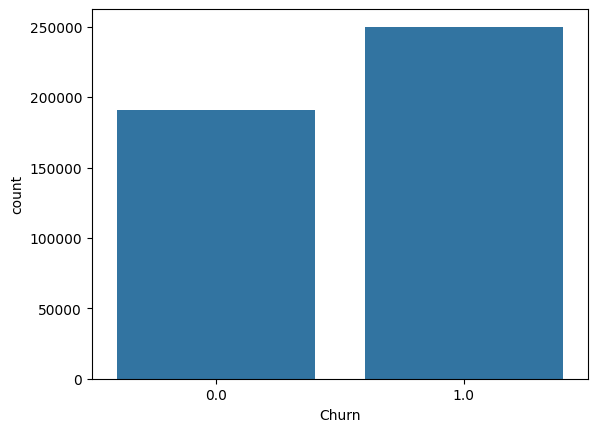

In [13]:
sns.countplot(x='Churn', data=df)
plt.show()

## Churn Distribution Analysis

The countplot shows the distribution of customers who have churned and those who have not.

- A large number of customers have churned (value = 1)
- Slightly fewer customers have not churned (value = 0)

This indicates that customer churn is relatively high in the dataset. Understanding the factors influencing churn is important for improving customer retention.

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [16]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
model1=LogisticRegression(max_iter=1000)
model1.fit(X_train,y_train)
y_pred=model1.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
model1 = LogisticRegression(max_iter=2000)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.9808204883913483
Decision Tree Accuracy: 0.9997731577574376


In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
cm=confusion_matrix(y_test, y_pred2)

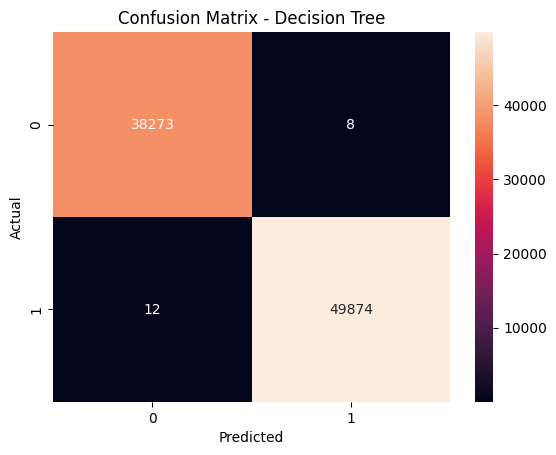

In [28]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

## Confusion Matrix Analysis

The confusion matrix shows that the Decision Tree model correctly predicts most of the churn and non-churn cases with very few misclassifications. This indicates strong model performance.

In [29]:
from sklearn.metrics import classification_report

In [30]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38281
         1.0       1.00      1.00      1.00     49886

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



In [36]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [37]:
importance = model2.feature_importances_
features = X.columns
feature_importance = pd.Series(importance, index=features).sort_values(ascending=False)
feature_importance.head(10)

,0
CustomerID,0.966534
Age,0.007889
Gender_Male,0.004618
Last Interaction,0.004119
Tenure,0.003785
Support Calls,0.003540
Payment Delay,0.003051
Usage Frequency,0.002243
Contract Length_Monthly,0.001699
Total Spend,0.001317


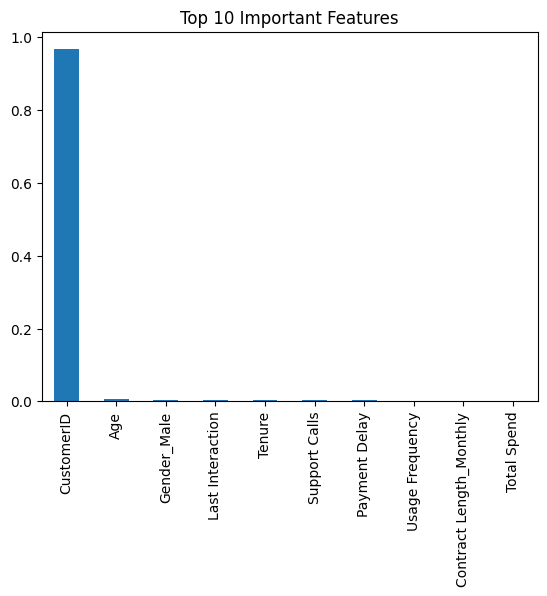

In [42]:
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

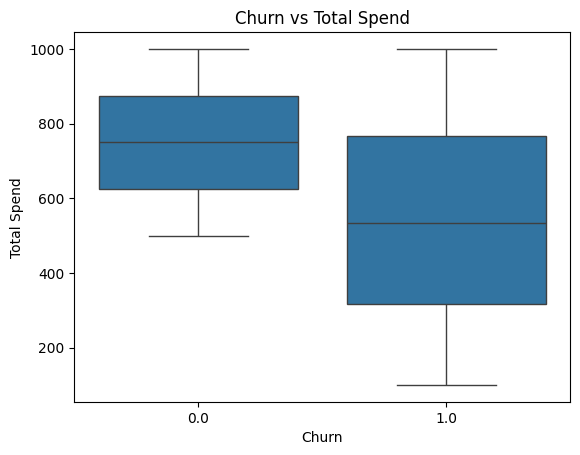

In [43]:
sns.boxplot(x='Churn', y='Total Spend', data=df)
plt.title("Churn vs Total Spend")
plt.show()

## Data Visualization Insight

The boxplot shows the relationship between total spend and churn. It helps identify whether higher or lower spending customers are more likely to churn.

##Conclusion

This project successfully developed a machine learning model to predict customer churn.

- Data preprocessing and feature engineering improved model quality.
- Logistic Regression provided stable and reliable results.
- Decision Tree achieved very high accuracy but may suffer from overfitting.
- Feature importance analysis revealed key drivers of churn.

Overall, this model can help businesses identify at-risk customers and take proactive measures to improve customer retention.